# 3. QPE on real quantum hardware

**Goal 3:** run the implementation on an actual quantum computer and compare against the
simulator. Three stages, so that a discrepancy can be attributed: **ideal simulator** (no
noise, establishes the answer), **noise model cloned from a real device** (isolates noise
from everything else about running on a real machine), **real hardware**.

The experiment is deliberately small, since estimation qubit j applies U 2^j times and the
inverse QFT adds a dense block of controlled rotations:

- **3 estimation qubits**, so 7 applications of U;
- **U = T**, giving θ = 1/8, exactly representable, so the ideal answer is a single
  outcome with probability 1 and any other weight is unambiguously error;
- **|1⟩ as the eigenstate**, one X gate to prepare.

Experiment 2, further down, drops the exactly-representable assumption.

In [1]:
import sys, json, pathlib
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import TGate, PhaseGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qpe import qpe_circuit
from qpe.analysis import best_phase, counts_to_phases, plot_stage_comparison
from qpe.backends import get_backend, run_circuit
from qpe.runs import collect_recorded, load_device_results, submit_and_record

plt.rcParams["figure.dpi"] = 110

TRUE_THETA = 1/8
N_EVAL = 3
SHOTS = 4096
DATA_DIR = pathlib.Path("../data")

# One colour per device, so a device keeps its colour across both experiments.
DEVICE_COLOURS = {"ibm_fez": "#C44E52", "ibm_marrakesh": "#8172B2", "ibm_kingston": "#937860"}

def job_paths(experiment: str, device: str):
    """(pending job-id file, result file) for an experiment/device pair."""
    return (DATA_DIR / f"hardware_{experiment}_{device}_job_id.json",
            DATA_DIR / f"hardware_qpe_{experiment}_{device}.json")

prep = QuantumCircuit(1, name="|1>")
prep.x(0)

circuit = qpe_circuit(TGate(), N_EVAL, prep)
print(f"target phase : {TRUE_THETA}  =  {int(TRUE_THETA * 2**N_EVAL):0{N_EVAL}b}_2")
print(f"qubits       : {circuit.num_qubits}")
print(f"logical depth: {circuit.depth()}")

target phase : 0.125  =  001_2
qubits       : 4
logical depth: 6


## Stage 1: ideal simulator

The reference answer.

In [2]:
ideal_counts = run_circuit(circuit, "aer", shots=SHOTS)
ideal = best_phase(ideal_counts, N_EVAL)

print(f"estimate    : {ideal.phase}")
print(f"probability : {ideal.probability:.4f}")
print(f"error       : {ideal.error_vs(TRUE_THETA):.2e}")

estimate    : 0.125
probability : 1.0000
error       : 0.00e+00


## What transpilation does to the circuit

The logical depth above is measured in abstract gates; the transpiled depth, after
rewriting into the device basis and mapping onto its connectivity, is what actually runs.
The gap between them is the best single predictor of how badly a NISQ device will do, and
two-qubit gates dominate the error budget.

In [3]:
FAKE_BACKEND = "fake:FakeManilaV2"   # 5-qubit device; enough for 3 eval + 1 target
handle = get_backend(FAKE_BACKEND)

pm = generate_preset_pass_manager(optimization_level=1, backend=handle.backend, seed_transpiler=42)
isa = pm.run(circuit)

print(f"device            : {handle.name}")
print(f"logical depth     : {circuit.depth():>5}   ops: {dict(circuit.count_ops())}")
print(f"transpiled depth  : {isa.depth():>5}")
print(f"transpiled 2q gates: {sum(v for k, v in isa.count_ops().items() if k in ('cx', 'ecr', 'cz')):>4}")

device            : FakeManilaV2
logical depth     :     6   ops: {'h': 3, 'measure': 3, '|1>': 1, 'ct^1': 1, 'ct^2': 1, 'ct^4': 1, 'qft_dg': 1}
transpiled depth  :    60
transpiled 2q gates:   35


## Stage 2: simulated noise from a real device

`AerSimulator.from_backend()` clones a real device's noise model, coupling map and basis
gates. This runs locally and instantly, needs no account, and is an honest preview of what
hardware will produce.

In [4]:
noisy_counts = run_circuit(circuit, FAKE_BACKEND, shots=SHOTS)
noisy = best_phase(noisy_counts, N_EVAL)

print(f"estimate    : {noisy.phase}")
print(f"probability : {noisy.probability:.4f}   (ideal: {ideal.probability:.4f})")
print(f"error       : {noisy.error_vs(TRUE_THETA):.4f}")
print()
print("Weight leaked to wrong outcomes:", f"{1 - noisy.probability:.1%}")

estimate    : 0.125
probability : 0.6504   (ideal: 1.0000)
error       : 0.0000

Weight leaked to wrong outcomes: 35.0%


## Stage 3: real hardware

Requires credentials (see [`.env.example`](../.env.example)), and the job queues. Hence
two cells rather than one: **submit** returns as soon as the job is accepted and writes
its id to disk, **collect** reads that id back and waits. A single blocking call would
tie the run to one live kernel and lose a job already charged to the account.

Both are off by default, and the collected result is cached to `data/`, so everything
below renders without an account.

In [5]:
hardware = load_device_results(DATA_DIR, "t_gate")

for device, result in hardware.items():
    print(f"{device:16s} {result['date'][:10]}  shots {result['shots']}  depth {result['transpiled_depth']}")
if not hardware:
    print("No saved hardware results. Set credentials in .env and run the submit cell below.")

ibm_fez          2026-07-22  shots 4096  depth 139
ibm_marrakesh    2026-07-22  shots 4096  depth 139


In [6]:
# --- Step 1: submit to real hardware -------------------------------------------------
# Set RUN_ON_HARDWARE = True and execute this cell ONCE per device, then set it back to
# False so a later "Run All" does not submit again.
#
# This only submits: submit_and_record writes the job id to disk the moment the job is
# accepted, so a job that queues for hours survives this kernel dying.
RUN_ON_HARDWARE = False
DEVICE = "ibm_fez"          # or "ibm_marrakesh", "ibm_kingston"; None = least busy

if RUN_ON_HARDWARE:
    handle_hw = get_backend(f"ibm:{DEVICE}" if DEVICE else "ibm")
    pending, _ = job_paths("t_gate", handle_hw.name)
    print(f"submitting to {handle_hw.name} ...")

    job, isa_hw = submit_and_record(
        circuit, handle_hw, pending, shots=SHOTS,
        metadata={"true_theta": TRUE_THETA, "num_eval_qubits": N_EVAL},
    )

    print(f"job id : {job.job_id()}   depth {isa_hw.depth()}")
    print(f"recorded in {pending}. Collect it with the next cell.")
else:
    print("RUN_ON_HARDWARE is False, not submitting.")

RUN_ON_HARDWARE is False, not submitting.


In [7]:
# --- Step 2: collect the submitted job -----------------------------------------------
# Set COLLECT_JOB = True to fetch the result for DEVICE above, then set it back to False.
# Safe to run in a fresh kernel days later: collect_recorded locates the job by the id on
# disk, not by any object in memory. It blocks until the job leaves the queue.
COLLECT_JOB = False

if COLLECT_JOB:
    pending, result_path = job_paths("t_gate", DEVICE)
    counts = collect_recorded(pending, result_path)
    hardware = load_device_results(DATA_DIR, "t_gate")
    print(f"saved to {result_path}: {best_phase(counts, N_EVAL)}")
else:
    print("COLLECT_JOB is False, nothing to collect.")

COLLECT_JOB is False, nothing to collect.


## Comparison

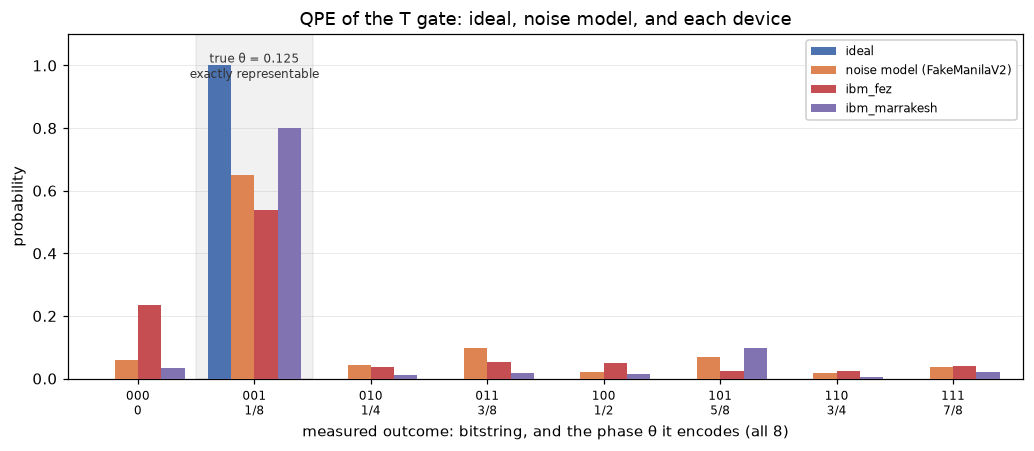

                         run   estimate   P(correct)     error
--------------------------------------------------------------
                       ideal     0.1250       1.0000    0.0000
  noise model (FakeManilaV2)     0.1250       0.6504    0.0000
                     ibm_fez     0.1250       0.5369    0.0000
               ibm_marrakesh     0.1250       0.8003    0.0000


In [8]:
series = [
    ("ideal", ideal_counts, "#4C72B0"),
    (f"noise model ({handle.name})", noisy_counts, "#DD8452"),
]
series += [
    (device, result["counts"], DEVICE_COLOURS.get(device, "#666666"))
    for device, result in hardware.items()
]

plot_stage_comparison(
    series, N_EVAL, true_phase=TRUE_THETA,
    title="QPE of the T gate: ideal, noise model, and each device",
)
plt.tight_layout(); plt.show()

print(f"{'run':>28} {'estimate':>10} {'P(correct)':>12} {'error':>9}")
print("-" * 62)
for label, counts, _ in series:
    est = best_phase(counts, N_EVAL)
    p_correct = counts_to_phases(counts, N_EVAL).get(TRUE_THETA, 0.0)
    print(f"{label:>28} {est.phase:>10.4f} {p_correct:>12.4f} {est.error_vs(TRUE_THETA):>9.4f}")

## Reading the result

Every run returns θ = 1/8. Noise costs confidence, not correctness — but how much
confidence depends strongly on the machine:

| run | P(correct) |
|---|---|
| ideal | 1.000 |
| noise model, `FakeManilaV2` | ~0.65 |
| `ibm_marrakesh` | 0.800 |
| `ibm_fez` | 0.537 |

Same circuit, same depth (139 after transpilation on both), same day, and `ibm_fez` loses
almost half its weight while `ibm_marrakesh` loses a fifth. A single hardware number is a
statement about one machine, not about QPE.

The leakage is not uniform, and the two devices fail *differently*. On `ibm_fez` the error
piles onto `000` (23.4%), the all-zeros string: amplitude damping toward |0⟩ plus readout
that misreads 1 as 0 more often than the reverse. On `ibm_marrakesh` `000` takes only
3.3%, and the error goes to `101` (9.6%) instead, which is the correct answer with its
**most significant bit** flipped. Experiment 2 below shows the same split again, which is
what makes it a device signature rather than a coincidence.

## How this scales: why we kept n small

In [9]:
print(f"{'n':>3} {'ideal P':>9} {'noisy P':>9} {'transpiled depth':>18}")
print("-" * 44)
for n in range(1, 5):
    c = qpe_circuit(TGate(), n, prep)
    d = generate_preset_pass_manager(optimization_level=1, backend=handle.backend,
                                     seed_transpiler=42).run(c).depth()
    pi = counts_to_phases(run_circuit(c, "aer", shots=2048), n).get(TRUE_THETA, 0.0)
    pn = counts_to_phases(run_circuit(c, FAKE_BACKEND, shots=2048), n).get(TRUE_THETA, 0.0)
    print(f"{n:>3} {pi:>9.4f} {pn:>9.4f} {d:>18}")

  n   ideal P   noisy P   transpiled depth
--------------------------------------------


  1    0.0000    0.0000                 10


  2    0.0000    0.0000                 31


  3    1.0000    0.6528                 60


  4    1.0000    0.4536                113


At n = 1, 2 the phase 1/8 is not representable, so those rows are limited by *resolution*,
not noise. From n = 3 the ideal run is exact while the noisy one degrades with depth.

---

# Experiment 2: a phase that is not representable

θ = 1/8 was chosen to be diagnostically clean: the ideal distribution is a single spike,
so any other weight is unambiguously error. The general case is not like that.

For θ = 0.2 with n = 3, the answer falls between `001` and `010`. No outcome is correct;
QPE returns the sinc-like spread centred on the true value. Success stops being binary:
what has to survive noise is the *shape*, not a single peak.

In [10]:
THETA_B = 0.2
circuit_b = qpe_circuit(PhaseGate(2 * np.pi * THETA_B), N_EVAL, prep)

ideal_counts_b = run_circuit(circuit_b, "aer", shots=SHOTS)
noisy_counts_b = run_circuit(circuit_b, FAKE_BACKEND, shots=SHOTS)

est_b = best_phase(ideal_counts_b, N_EVAL)
print(f"true theta          : {THETA_B}  ->  {THETA_B * 2**N_EVAL:.1f}/{2**N_EVAL}, between outcomes")
print(f"ideal modal estimate: {est_b.phase}   p = {est_b.probability:.4f}")
print(f"ideal circular mean : {est_b.mean_phase():.4f}   error = {abs(est_b.mean_phase() - THETA_B):.4f}")

true theta          : 0.2  ->  1.6/8, between outcomes
ideal modal estimate: 0.25   p = 0.5767
ideal circular mean : 0.2127   error = 0.0127


### Running experiment 2 on hardware

Same two-step submit/collect as before, writing to its own pair of files so the first
experiment's result is never overwritten. Both flags are off by default.

In [11]:
hardware_b = load_device_results(DATA_DIR, "theta_0.2")

for device, result in hardware_b.items():
    print(f"{device:16s} {result['date'][:10]}  shots {result['shots']}  depth {result['transpiled_depth']}")
if not hardware_b:
    print("No saved hardware results for experiment 2 yet.")

ibm_fez          2026-07-22  shots 4096  depth 139
ibm_marrakesh    2026-07-22  shots 4096  depth 139


In [12]:
# --- Experiment 2, step 1: submit ----------------------------------------------------
# Set to True, run once per device, then set back to False.
RUN_ON_HARDWARE_B = False
DEVICE_B = "ibm_fez"        # or "ibm_marrakesh", "ibm_kingston"

if RUN_ON_HARDWARE_B:
    handle_hw_b = get_backend(f"ibm:{DEVICE_B}")
    pending_b, _ = job_paths("theta_0.2", handle_hw_b.name)
    print(f"submitting to {handle_hw_b.name} ...")

    job_b, isa_hw_b = submit_and_record(
        circuit_b, handle_hw_b, pending_b, shots=SHOTS,
        metadata={"true_theta": THETA_B, "num_eval_qubits": N_EVAL},
    )

    print(f"job id : {job_b.job_id()}   depth {isa_hw_b.depth()}")
else:
    print("RUN_ON_HARDWARE_B is False, not submitting.")

RUN_ON_HARDWARE_B is False, not submitting.


In [13]:
# --- Experiment 2, step 2: collect ---------------------------------------------------
COLLECT_JOB_B = False

if COLLECT_JOB_B:
    pending_b, result_path_b = job_paths("theta_0.2", DEVICE_B)
    counts_b = collect_recorded(pending_b, result_path_b)
    hardware_b = load_device_results(DATA_DIR, "theta_0.2")
    print(f"saved to {result_path_b}: {best_phase(counts_b, N_EVAL)}")
else:
    print("COLLECT_JOB_B is False, nothing to collect.")

COLLECT_JOB_B is False, nothing to collect.


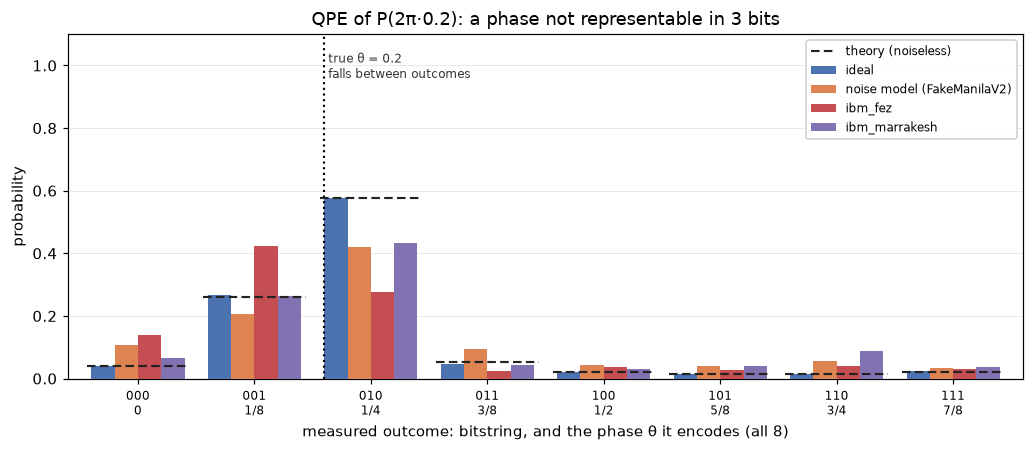

                         run     mode   P(mode)   circ. mean   mean error
-------------------------------------------------------------------------
                       ideal    0.250    0.5767       0.2127       0.0127
  noise model (FakeManilaV2)    0.250    0.4187       0.2090       0.0090
                     ibm_fez    0.125    0.4248       0.1468       0.0532
               ibm_marrakesh    0.250    0.4321       0.1928       0.0072


In [14]:
series_b = [
    ("ideal", ideal_counts_b, "#4C72B0"),
    (f"noise model ({handle.name})", noisy_counts_b, "#DD8452"),
]
series_b += [
    (device, result["counts"], DEVICE_COLOURS.get(device, "#666666"))
    for device, result in hardware_b.items()
]

plot_stage_comparison(
    series_b, N_EVAL, true_phase=THETA_B, show_theory=True,
    title=f"QPE of P(2π·{THETA_B}): a phase not representable in {N_EVAL} bits",
)
plt.tight_layout(); plt.show()

print(f"{'run':>28} {'mode':>8} {'P(mode)':>9} {'circ. mean':>12} {'mean error':>12}")
print("-" * 73)
for label, counts, _ in series_b:
    est = best_phase(counts, N_EVAL)
    mean = est.mean_phase()
    print(f"{label:>28} {est.phase:>8.3f} {est.probability:>9.4f} {mean:>12.4f} {abs(mean - THETA_B):>12.4f}")

In [15]:
# Same circuit, different machines: where does each one send its lost weight?
# For each experiment, take the ideal peak and ask which single-bit corruption of it
# absorbs the error. Bit 2 is the MSB, the estimation qubit that applies U^4.
def leakage_profile(counts, peak_bits):
    dist = counts_to_phases(counts, N_EVAL)
    peak = int(peak_bits, 2)
    total = 2**N_EVAL
    return {
        "peak": dist.get(peak / total, 0.0),
        "MSB flip": dist.get((peak ^ 0b100) / total, 0.0),
        "mid flip": dist.get((peak ^ 0b010) / total, 0.0),
        "LSB flip": dist.get((peak ^ 0b001) / total, 0.0),
        "-> 000": dist.get(0.0, 0.0),
    }

cols = ["peak", "MSB flip", "mid flip", "LSB flip", "-> 000"]
for experiment, results, peak_bits in (
    ("T gate, peak 001", hardware, "001"),
    ("θ=0.2, peak 010", hardware_b, "010"),
):
    print(experiment)
    print(f"{'device':>16} " + " ".join(f"{c:>9}" for c in cols))
    for device, result in results.items():
        p = leakage_profile(result["counts"], peak_bits)
        print(f"{device:>16} " + " ".join(f"{p[c]:>9.3f}" for c in cols))
    print()

T gate, peak 001
          device      peak  MSB flip  mid flip  LSB flip    -> 000
         ibm_fez     0.537     0.024     0.054     0.234     0.234
   ibm_marrakesh     0.800     0.096     0.018     0.033     0.033

θ=0.2, peak 010
          device      peak  MSB flip  mid flip  LSB flip    -> 000
         ibm_fez     0.277     0.042     0.138     0.024     0.138
   ibm_marrakesh     0.432     0.089     0.065     0.044     0.065



### Reading experiment 2

The tail is present in the noiseless run and tracks the theory ticks: it is QPE's
resolution limit, not error.

**The stricter test splits the devices.** With no single correct outcome, what has to
survive is the ordering of the two straddling bars, `010` (theory 0.575) above `001`
(theory 0.259).

| run | mode | P(mode) | `010` | `001` | circ. mean |
|---|---|---|---|---|---|
| ideal | 0.250 | 0.575 | 0.575 | 0.259 | 0.217 |
| `ibm_marrakesh` | 0.250 | 0.432 | 0.432 | 0.264 | 0.193 |
| `ibm_fez` | **0.125** | 0.425 | 0.277 | 0.425 | 0.147 |

`ibm_marrakesh` holds the ordering and reproduces the lower neighbour at 0.264 against a
theoretical 0.259. **`ibm_fez` inverts it**: `001` overtakes `010` and the modal estimate
moves to the wrong grid point, 0.125 instead of 0.250. Experiment 1 could not have
revealed this. There, `ibm_fez` had a comfortable margin and reported the right answer;
here the same damping that produced its `000` excess drags weight downward across the
peak, and once it crosses the neighbour the estimate is simply wrong.

**Mode versus mean.** The mode is pinned to the grid, so its error cannot fall below the
resolution. The circular mean is free to land between grid points: 0.217 ideal, 0.193 on
`ibm_marrakesh`, 0.147 on `ibm_fez`. Note the mean degrades smoothly with device quality
while the mode fails discontinuously — it is right until it is suddenly a whole grid step
out.

**The `mean error` column is treacherous.** The `FakeManilaV2` run beats the *ideal* one
there. That is not accuracy: the ideal mean is biased high (0.217 against 0.200) by the
asymmetric tail, noise pushes weight downward, and the two partly cancel. A scalar cannot
distinguish accurate from wrong in two compensating ways, hence the theory ticks.

**The device signature repeats.** The leakage table shows `ibm_marrakesh` losing 8.9% to
the MSB flip of its peak in this experiment, against 9.6% in experiment 1 — the same
qubit, the estimation qubit that applies U⁴ and therefore sits in the circuit longest.
`ibm_fez` instead sends 13.8% to `000` here and 23.4% there. Two machines, two stable and
quite different error mechanisms, neither of which the static `FakeManilaV2` model
predicts.

## Summary

| stage | what it isolates |
|---|---|
| ideal simulator | the algorithm, with no error |
| device noise model | realistic gate/readout error, locally and for free |
| real hardware | everything else: drift, calibration age, crosstalk |

| experiment | `ibm_marrakesh` | `ibm_fez` |
|---|---|---|
| θ = 1/8, representable | correct, P = 0.800 | correct, P = 0.537 |
| θ = 0.2, between outcomes | shape held, mode correct | ordering inverted, mode wrong |

Running one circuit on one device would have supported either "QPE survives NISQ noise" or
"QPE fails on a general phase". Both statements are too strong; which one you reach depends
on the machine you were allocated.

Next: [`04_hhl.ipynb`](04_hhl.ipynb) reuses this QPE implementation as a subroutine inside
HHL.